## Step 1: Load data and rebuild focal_term → PMID mapping

In [339]:
import pandas as pd

# Raw sources
df_pat  = pd.read_parquet('SampleGloria_Pat_GlinerLabels.parquet')   # patent_id, term
df_pmed = pd.read_parquet('SampleGloria_Pmed_GlinerLabels.parquet')  # pmid (int), term
df_link = pd.read_parquet('SampleGloria_Link_PmidOa.parquet')        # patent_id, pmid (URL)

# Pre-computed focal terms (aggregated)
df_focal = pd.read_parquet('output_dataset/focal_terms.parquet')     # patent_id, focal_term

print('Pat rows:  ', len(df_pat))
print('Pmed rows: ', len(df_pmed))
print('Link rows: ', len(df_link))
print('Focal rows:', len(df_focal))

Pat rows:   23312
Pmed rows:  31831
Link rows:  6104
Focal rows: 790


In [340]:
# Clean link table: extract numeric pmid from URL, drop rows without pmid
df_link_clean = df_link.dropna(subset=['pmid']).copy()
df_link_clean['pmid'] = df_link_clean['pmid'].str.extract(r'(\d+)$').astype('int32')
df_link_clean = df_link_clean[['patent_id', 'pmid']].drop_duplicates()
print('patent-pmid pairs:', len(df_link_clean))

patent-pmid pairs: 3997


In [341]:
# Merge pmed terms with patent_id via the link table
cited_terms = df_pmed[['pmid', 'term']].merge(df_link_clean, on='pmid', how='inner')

# Rebuild focal_terms_with_pmid:
#   A (patent_id, term) is a focal term if it appears in both
#   the patent AND in at least one cited paper of that patent.
patent_term_set = df_pat[['patent_id', 'term']].drop_duplicates()
focal_with_pmid = patent_term_set.merge(
    cited_terms[['patent_id', 'pmid', 'term']].drop_duplicates(),
    on=['patent_id', 'term'],
    how='inner'
).rename(columns={'term': 'focal_term'})

print('focal_with_pmid shape:', focal_with_pmid.shape)
focal_with_pmid.head()

focal_with_pmid shape: (1743, 3)


,patent_id,focal_term,pmid
0,7662783,effective,17483349
1,7662783,antagonist,11387236
2,7662783,collagen,11387236
3,7662783,collagen,11535623
4,7662783,collagen,17110907


## Step 2: Build patent context per (patent_id, focal_term)

Patent context = **set of all terms in the patent** minus the focal term itself.

In [342]:
# Unique terms per patent (as a dict: patent_id -> frozenset of terms)
patent_term_sets = (
    df_pat.groupby('patent_id')['term']
          .apply(set)
          .to_dict()
)
print('Patents with term sets:', len(patent_term_sets))

Patents with term sets: 252


## Step 3: Build paper context per (patent_id, focal_term)

Paper context = **set of all terms** in the PMIDs where the focal term appears (for that patent) minus the focal term.

In [343]:
# For each (patent_id, focal_term) → set of relevant PMIDs
focal_pmids = (
    focal_with_pmid.groupby(['patent_id', 'focal_term'])['pmid']
                   .apply(set)
                   .reset_index(name='pmid_set')
)

# Build a dict: pmid -> set of terms (from pmed)
pmid_term_sets = (
    df_pmed.groupby('pmid')['term']
           .apply(set)
           .to_dict()
)
print('PMIDs with term sets:', len(pmid_term_sets))

PMIDs with term sets: 706


In [344]:
def paper_context(pmid_set, focal_term):
    """Union of terms across the relevant PMIDs, minus the focal term."""
    terms = set()
    for pmid in pmid_set:
        terms |= pmid_term_sets.get(pmid, set())
    terms.discard(focal_term)
    return terms

focal_pmids['paper_ctx'] = focal_pmids.apply(
    lambda r: paper_context(r['pmid_set'], r['focal_term']), axis=1
)
focal_pmids.head(3)

,patent_id,focal_term,pmid_set,paper_ctx
0,7662783,alpha,{11387236},"{chain, functional, wound, binding, laminin, s..."
1,7662783,antagonist,{11387236},"{chain, functional, wound, binding, laminin, s..."
2,7662783,cell,"{12746434, 11535623, 12071856, 12454288, 17483...","{existence, sequence, nearly, human, laminin, ..."


In [345]:
rows = []
for _, row in focal_pmids.iterrows():
    pid   = row['patent_id']
    ft    = row['focal_term']
    
    # Patent context: all patent terms minus the focal term
    pat_ctx = patent_term_sets.get(pid, set()) - {ft}
    
    # Paper context already computed
    pap_ctx = row['paper_ctx']
    
    
    rows.append({
        'patent_id':          pid,
        'focal_term':         ft,
        'pmids':              row['pmid_set'],
        'patent_context':     pat_ctx,
        'paper_context':      pap_ctx
    })

focal_term_contexts = pd.DataFrame(rows)
focal_term_contexts.to_parquet("./output_dataset/focal_term_context.parquet")
focal_term_contexts.head()


,patent_id,focal_term,pmids,patent_context,paper_context
0,7662783,alpha,{11387236},"{sequence, ovary, method, uterus, bone, prolif...","{chain, functional, wound, binding, laminin, s..."
1,7662783,antagonist,{11387236},"{sequence, ovary, method, uterus, bone, prolif...","{chain, functional, wound, binding, laminin, s..."
2,7662783,cell,"{12746434, 11535623, 12071856, 12454288, 17483...","{sequence, ovary, method, uterus, bone, prolif...","{existence, sequence, nearly, human, laminin, ..."
3,7662783,collagen,"{17110907, 11387236, 11535623}","{sequence, ovary, method, uterus, bone, prolif...","{nearly, functional, significant, binding, lam..."
4,7662783,colon,{12746434},"{sequence, ovary, method, uterus, bone, prolif...","{apo, significant, anti-angiogenic, human, sug..."


In [346]:
patent_sentences = [f"{row['focal_term']} {' '.join(row['patent_context'])}" for _, row in focal_term_contexts.iterrows()]
patent_sentences                               

['alpha sequence ovary method uterus bone proliferation amino acid sequence effect beams treating melanoma kaposi neuroblastoma larynx amount lymph node synergistic sensitivity sweat gland tumor effective liver comprises treatment bladder about collagen colon comprising neutron neutrons particles electron growth administering cervix tumors glioblastoma lung colorectal radiation radiation therapy combination total stomach least breast testicle prostate electrons head at therapy x-rays skin gamma endometrius pharynx peptide patient beta pancreas neck amino acid solid tumor negative pi mesons sarcoma solid marrow joint gy increases intestine cell administered proton kidney antagonist',
 'antagonist sequence ovary method uterus bone proliferation amino acid sequence effect beams treating melanoma kaposi neuroblastoma larynx amount lymph node synergistic sensitivity sweat gland tumor effective liver comprises treatment bladder about collagen colon comprising neutron neutrons particles elect

In [347]:
paper_sentences = [f"{row['focal_term']} {' '.join(row['paper_context'])}" for _, row in focal_term_contexts.iterrows()]
paper_sentences  

['alpha chain functional wound binding laminin surface adhesion important potent bind and alpha5beta1 fibronectin healing gamma1 site metastasis phosphorylation vivo peptide activity tumor matrix capillary-like collagen differentiate likely ubiquitous α5β1 laminin-1 beta3 therapeutic αvβ3 receptor growth chromatography role attachment angiogenic screening antagonist block',
 'antagonist chain functional wound binding laminin surface adhesion important potent bind and alpha5beta1 fibronectin healing gamma1 site metastasis phosphorylation vivo peptide activity alpha tumor matrix capillary-like collagen differentiate likely ubiquitous α5β1 laminin-1 beta3 therapeutic αvβ3 receptor growth chromatography role attachment angiogenic screening block',
 'cell existence sequence nearly human laminin selective mg from suggest integrin presence daily invasive injury effect apparent phenotype anti-tumor support specificity proteolysis umbilical phage chick kringle domain elucidate expression furthe

In [348]:
from sentence_transformers import SentenceTransformer
#sentences = ["This is an example sentence", "Each sentence is converted"]

#model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
#embeddings = model.encode(sentences)
 #print(embeddings)


In [349]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode both lists — index i of patent_embeddings corresponds to index i of paper_embeddings
patent_embeddings = model.encode(patent_sentences, show_progress_bar=True)
paper_embeddings  = model.encode(paper_sentences,  show_progress_bar=True)

print("patent_embeddings shape:", patent_embeddings.shape)
print("paper_embeddings shape: ", paper_embeddings.shape)

# Quick sanity check: first pair
print("\nFirst patent sentence:", patent_sentences[0][:80], "...")
print("First paper sentence: ", paper_sentences[0][:80], "...")
print("patent_embeddings[0]:", patent_embeddings[0][:5], "...")
print("paper_embeddings[0]: ", paper_embeddings[0][:5], "...")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6161.06it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 25/25 [00:03<00:00,  6.82it/s]


patent_embeddings shape: (790, 384)
paper_embeddings shape:  (790, 384)

First patent sentence: alpha sequence ovary method uterus bone proliferation amino acid sequence effect ...
First paper sentence:  alpha chain functional wound binding laminin surface adhesion important potent b ...
patent_embeddings[0]: [-0.05803602 -0.01717084 -0.01142235 -0.02095601 -0.02512396] ...
paper_embeddings[0]:  [-0.08005483 -0.11467064 -0.0754515  -0.0189006   0.0735005 ] ...


In [350]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Cosine similarity between each patent/paper embedding pair (row-wise)
similarities = cosine_similarity(patent_embeddings, paper_embeddings).diagonal()

focal_term_contexts['cosine_similarity'] = similarities

print(focal_term_contexts[['patent_id', 'focal_term', 'cosine_similarity']].head(50))
focal_term_contexts.to_parquet("./output_dataset/cosine_similarity_results.parquet")

   patent_id       focal_term  cosine_similarity
0    7662783            alpha           0.363239
1    7662783       antagonist           0.352652
2    7662783             cell           0.337005
3    7662783         collagen           0.364990
4    7662783            colon           0.374241
5    7662783           effect           0.258402
6    7662783        effective           0.324087
7    7662783           growth           0.377879
8    7662783             lung           0.349962
9    7662783         melanoma           0.369801
10   7662783          peptide           0.392386
11   7662783    proliferation           0.389865
12   7662783         sequence           0.146766
13   7662783             skin           0.347670
14   7662783        treatment           0.369312
15   7662783            tumor           0.371695
16   7700783            agent           0.172730
17   7700783         hydroxyl           0.276096
18   7704363              and           0.284898
19   7704363    conc

Cosine Similarity Statistics
  Mean:   0.441
  Median: 0.443
  Std:    0.140
  Min:    -0.008
  Max:    0.843


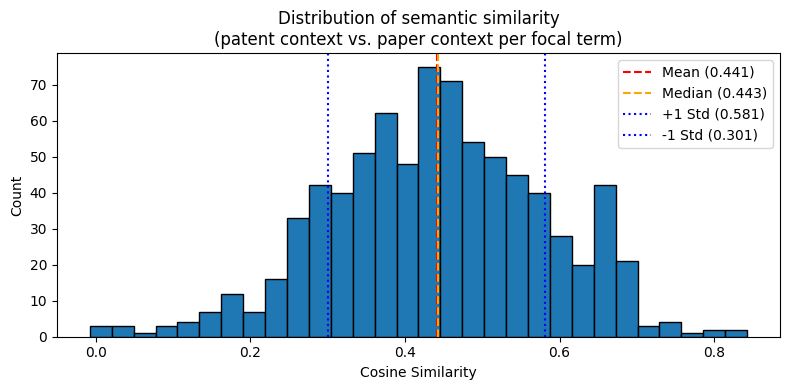

In [351]:
import matplotlib.pyplot as plt

sim = focal_term_contexts['cosine_similarity']

# --- Quantitative summary ---
print("Cosine Similarity Statistics")
print(f"  Mean:   {sim.mean():.3f}")
print(f"  Median: {sim.median():.3f}")
print(f"  Std:    {sim.std():.3f}")
print(f"  Min:    {sim.min():.3f}")
print(f"  Max:    {sim.max():.3f}")

# --- Histogram ---
plt.figure(figsize=(8, 4))
plt.hist(sim, bins=30, edgecolor='black')
plt.axvline(sim.mean(),              color='red',    linestyle='--', label=f'Mean ({sim.mean():.3f})')
plt.axvline(sim.median(),            color='orange', linestyle='--', label=f'Median ({sim.median():.3f})')
plt.axvline(sim.mean() + sim.std(),  color='blue',   linestyle=':',  label=f'+1 Std ({sim.mean()+sim.std():.3f})')
plt.axvline(sim.mean() - sim.std(),  color='blue',   linestyle=':',  label=f'-1 Std ({sim.mean()-sim.std():.3f})')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.title('Distribution of semantic similarity\n(patent context vs. paper context per focal term)')
plt.legend()
plt.tight_layout()
plt.savefig("visualizations/cosine_similarity_distribution.png", dpi=150)
plt.show()

In [352]:
n = 5  # number of examples to show

top = focal_term_contexts.nlargest(n, 'cosine_similarity')[['patent_id', 'focal_term', 'patent_context', 'paper_context', 'cosine_similarity']]
bot = focal_term_contexts.nsmallest(n, 'cosine_similarity')[['patent_id', 'focal_term', 'patent_context', 'paper_context', 'cosine_similarity']]

print("=== HIGH similarity (focal term used in similar contexts) ===")
for _, row in top.iterrows():
    print(f"\nFocal term: '{row['focal_term']}'  (patent_id={row['patent_id']},  sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx (sample): {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx (sample): {', '.join(list(row['paper_context'])[:10])}")

print("\n=== LOW similarity (focal term used in different contexts) ===")
for _, row in bot.iterrows():
    print(f"\nFocal term: '{row['focal_term']}'  (patent_id={row['patent_id']},  sim={row['cosine_similarity']:.3f})")
    print(f"  Patent ctx (sample): {', '.join(list(row['patent_context'])[:10])}")
    print(f"  Paper  ctx (sample): {', '.join(list(row['paper_context'])[:10])}")

=== HIGH similarity (focal term used in similar contexts) ===

Focal term: 'asbestos-related'  (patent_id=8168398,  sim=0.843)
  Patent ctx (sample): indicates, increased, having, method, human, in, assaying, concluded, mesothelioma, presence
  Paper  ctx (sample): significant, nonmalignant, mesothelioma, cancer, enzyme-linked, presence, disease, with, asbestos, milliliter

Focal term: 'asbestos'  (patent_id=8168398,  sim=0.820)
  Patent ctx (sample): indicates, increased, having, method, human, in, assaying, concluded, mesothelioma, presence
  Paper  ctx (sample): functional, significant, letter, radiograph, chemoprevention, mesothelioma, error, cancer, enzyme-linked, presence

Focal term: 'presence'  (patent_id=8168398,  sim=0.801)
  Patent ctx (sample): indicates, increased, having, method, human, in, assaying, concluded, mesothelioma, age-matched
  Paper  ctx (sample): significant, nonmalignant, mesothelioma, cancer, enzyme-linked, disease, with, asbestos, milliliter, normal

Focal